# E008 — Audio augmentation ablation

Mirrors E007 (image augmentation) but for audio. E003 (UBM+MAP) achieved
EER 7.45 ± 5.04% — the high variance and gap vs image suggest the model
is sensitive to session-specific acoustic conditions.

**Augmentation pipeline:**
```
WAV → [augment] → MFCC+Δ+ΔΔ → CMN → UBM/MAP
```
Augmentation is at the **signal level**, before feature extraction.
CMN (cepstral mean normalization) is still applied after — it normalizes
per utterance, so it works correctly on augmented signals too.

Val fold: original WAVs only. UBM and adapted model are trained on
augmented train frames.

Tested configs:
1. Baseline (= E003 exactly)
2. + Additive noise (SNR=20dB)
3. + Speed perturbation (rate ∈ [0.9, 1.1])
4. + All combined

In [1]:
from pathlib import Path
import sys, copy
sys.path.insert(0, str(Path("../src").resolve()))

import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_curve, auc
from scipy.special import logsumexp
from scipy.stats import norm as scipy_norm
import pandas as pd

from data.splits import load_manifest, iter_folds_loso
from eval.metrics import compute_eer, compute_min_dcf

COLORS = {
    "target":    "#E74C3C",
    "nontarget": "#2E86AB",
    "green":     "#27AE60",
    "purple":    "#8E44AD",
    "gray":      "#95A5A6",
    "orange":    "#E67E22",
}
CONFIG_COLORS = {
    "Baseline": "#95A5A6",
    "+Noise":   "#2E86AB",
    "+Speed":   "#E67E22",
    "+All":     "#E74C3C",
}
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

DATA = Path("../data").resolve()
manifest = load_manifest(DATA)
y_all = manifest["label"].to_numpy()
SEED = 67
print(f"{len(manifest)} samples — {manifest.label.sum()} target, {(manifest.label==0).sum()} non-target")

222 samples — 30 target, 192 non-target


## 1. Augmentation functions

All augmentations operate on the raw waveform `y` (float32 array).
MFCC extraction and CMN happen **after** augmentation.

In [2]:
def find_wav(stem: str, data_dir: Path) -> Path:
    for sf in ["target_train", "target_dev", "non_target_train", "non_target_dev"]:
        p = data_dir / sf / (stem + ".wav")
        if p.exists():
            return p
    raise FileNotFoundError(stem)


def aug_noise(y: np.ndarray, snr_db: float = 20.0, rng: np.random.Generator = None) -> np.ndarray:
    """Add white noise at target SNR."""
    signal_power = np.mean(y ** 2) + 1e-10
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise = rng.normal(0, np.sqrt(noise_power), len(y)).astype(y.dtype)
    return y + noise


def aug_speed(y: np.ndarray, rate_range=(0.9, 1.1), rng: np.random.Generator = None) -> np.ndarray:
    """Random time stretch without changing pitch."""
    rate = rng.uniform(*rate_range)
    return librosa.effects.time_stretch(y, rate=rate)


def extract_mfcc(y: np.ndarray, sr: int, n_mfcc: int = 13) -> np.ndarray:
    """MFCC + delta + delta-delta + CMN. Returns (T, 39)."""
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    mfcc   = np.vstack([mfcc, delta, delta2]).T
    mfcc  -= mfcc.mean(axis=0)  # CMN
    return mfcc


def load_and_augment(wav_path: Path, config: str, rng: np.random.Generator):
    """
    Load WAV and return list of (y, sr) tuples:
    - baseline: [original]
    - +noise:   [original, noisy]
    - +speed:   [original, speed-perturbed]
    - +all:     [original, noisy, speed-perturbed]
    """
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    samples = [(y, sr)]

    if config in ("noise", "all"):
        samples.append((aug_noise(y, snr_db=20.0, rng=rng), sr))
    if config in ("speed", "all"):
        samples.append((aug_speed(y, rng=rng), sr))

    return samples


def extract_batch(df: pd.DataFrame, data_dir: Path, config: str, seed: int):
    """Extract MFCC frames for all samples, with augmentation on train fold."""
    rng = np.random.default_rng(seed)
    all_mfcc, all_labels = [], []
    for _, row in df.iterrows():
        for y_aug, sr in load_and_augment(find_wav(row["stem"], data_dir), config, rng):
            mfcc = extract_mfcc(y_aug, sr)
            all_mfcc.append(mfcc)
            all_labels.extend([row["label"]] * len(mfcc))
    return np.vstack(all_mfcc), np.array(all_labels)


def extract_batch_original(df: pd.DataFrame, data_dir: Path):
    """Extract MFCC from original WAVs only (for val fold)."""
    all_mfcc, all_labels = [], []
    for _, row in df.iterrows():
        y, sr = librosa.load(find_wav(row["stem"], data_dir), sr=None, mono=True)
        mfcc = extract_mfcc(y, sr)
        all_mfcc.append(mfcc)
        all_labels.extend([row["label"]] * len(mfcc))
    return np.vstack(all_mfcc), np.array(all_labels)


print("Augmentation functions defined.")

Augmentation functions defined.


## 2. Augmentation visualization

What do the augmented signals look like? We visualize the waveform and
spectrogram to confirm augmentations are realistic — they should sound
like the same person under different conditions, not like a different person.

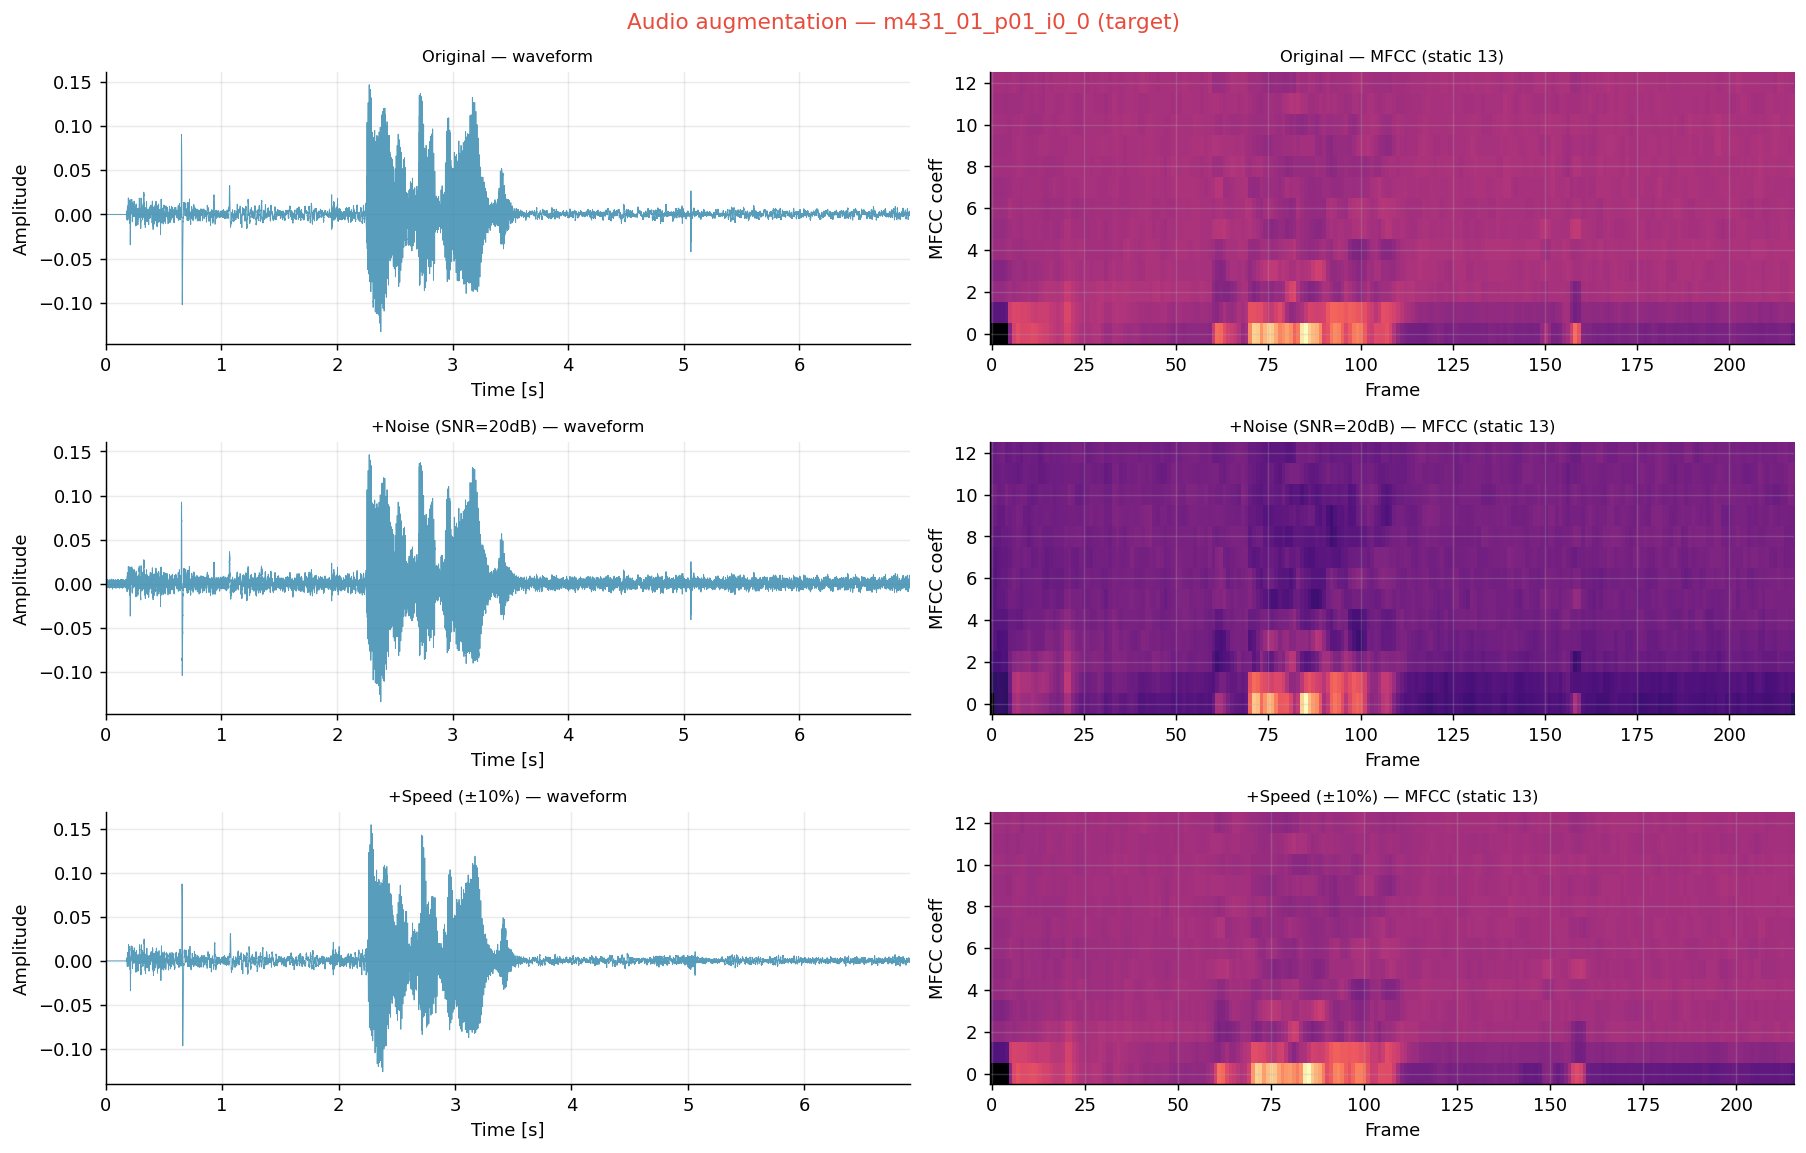

In [3]:
rng_viz = np.random.default_rng(42)
sample_row = manifest[manifest.label == 1].iloc[0]
y_orig, sr = librosa.load(find_wav(sample_row["stem"], DATA), sr=None, mono=True)

y_noisy = aug_noise(y_orig, snr_db=20.0, rng=rng_viz)
y_speed = aug_speed(y_orig, rng=rng_viz)

signals = {
    "Original": y_orig,
    "+Noise (SNR=20dB)": y_noisy,
    "+Speed (±10%)": y_speed,
}

fig, axes = plt.subplots(3, 2, figsize=(14, 9))
t_orig  = np.linspace(0, len(y_orig)/sr, len(y_orig))

for row_idx, (title, y_aug) in enumerate(signals.items()):
    t = np.linspace(0, len(y_aug)/sr, len(y_aug))

    # Waveform
    ax = axes[row_idx, 0]
    ax.plot(t, y_aug, color=COLORS["nontarget"], lw=0.5, alpha=0.8)
    ax.set_title(f"{title} — waveform", fontsize=9)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(0, max(t))

    # MFCC
    ax = axes[row_idx, 1]
    mfcc_aug = extract_mfcc(y_aug, sr)[:, :13]  # show only static MFCCs
    im = ax.imshow(mfcc_aug.T, aspect="auto", origin="lower", cmap="magma")
    ax.set_title(f"{title} — MFCC (static 13)", fontsize=9)
    ax.set_xlabel("Frame")
    ax.set_ylabel("MFCC coeff")

plt.suptitle(f"Audio augmentation — {sample_row['stem']} (target)",
             color=COLORS["target"], fontsize=12)
plt.tight_layout()
plt.show()

## 3. UBM + MAP functions (same as E003)

In [4]:
def train_ubm(X: np.ndarray, n_components: int = 32, seed: int = 67) -> GaussianMixture:
    return GaussianMixture(
        n_components=n_components, covariance_type="diag",
        max_iter=200, random_state=seed,
    ).fit(X)


def map_adapt(ubm: GaussianMixture, X_target: np.ndarray, r: float = 16.0) -> GaussianMixture:
    log_prob   = ubm._estimate_log_prob(X_target)
    log_resp   = log_prob + np.log(ubm.weights_)
    log_resp  -= logsumexp(log_resp, axis=1, keepdims=True)
    resp       = np.exp(log_resp)
    n_k        = resp.sum(axis=0)
    mu_hat     = (resp.T @ X_target) / (n_k[:, None] + 1e-10)
    alpha      = n_k / (n_k + r)
    adapted    = copy.deepcopy(ubm)
    adapted.means_ = alpha[:, None] * mu_hat + (1 - alpha[:, None]) * ubm.means_
    return adapted


def score_utterance(wav_path: Path, adapted: GaussianMixture, ubm: GaussianMixture) -> float:
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    mfcc  = extract_mfcc(y, sr)
    return float((adapted.score_samples(mfcc) - ubm.score_samples(mfcc)).mean())


print("UBM+MAP functions defined.")

UBM+MAP functions defined.


## 4. Cross-validation across all configs

For each config, the UBM and MAP-adapted model are trained on augmented
train frames. Val utterances are always scored from original WAVs.

In [5]:
UBM_COMPONENTS = 32
MAP_R = 16.0

CONFIGS = {
    "baseline": "Baseline",
    "noise":    "+Noise",
    "speed":    "+Speed",
    "all":      "+All",
}

all_results = {}
all_oof     = {}

for config_key, config_name in CONFIGS.items():
    print(f"\n{'='*50}")
    print(f"Config: {config_name}")
    print('='*50)

    oof_scores   = np.full(len(manifest), np.nan)
    fold_results = []

    for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
        train_df = manifest.loc[train_idx]
        val_df   = manifest.loc[val_idx]

        # Extract augmented train frames (only train fold!)
        X_train, y_train = extract_batch(train_df, DATA, config_key, seed=SEED+fold_id)
        X_nt = X_train[y_train == 0]
        X_t  = X_train[y_train == 1]

        print(f"  Fold {fold_id}: {len(X_t)} target frames, {len(X_nt)} non-target frames (aug)")

        ubm     = train_ubm(X_nt, n_components=UBM_COMPONENTS, seed=SEED)
        adapted = map_adapt(ubm, X_t, r=MAP_R)

        # Score val on ORIGINAL WAVs only
        for idx, row in val_df.iterrows():
            oof_scores[idx] = score_utterance(find_wav(row["stem"], DATA), adapted, ubm)

        val_scores = oof_scores[val_idx]
        val_labels = manifest.loc[val_idx, "label"].to_numpy()
        eer, _     = compute_eer(val_scores[val_labels==1], val_scores[val_labels==0])
        min_dcf, _ = compute_min_dcf(val_scores[val_labels==1], val_scores[val_labels==0])
        fold_results.append({"fold": fold_id, "eer": eer, "min_dcf": min_dcf})
        print(f"  → EER={eer*100:.2f}%, min-DCF={min_dcf:.4f}")

    all_results[config_name] = fold_results
    all_oof[config_name]     = oof_scores.copy()

print("\nAll configs done.")


Config: Baseline
  Fold 0: 5102 target frames, 56982 non-target frames (aug)
  → EER=9.86%, min-DCF=0.1389
  Fold 1: 5540 target frames, 59888 non-target frames (aug)
  → EER=10.83%, min-DCF=0.1333
  Fold 2: 5684 target frames, 62852 non-target frames (aug)
  → EER=1.67%, min-DCF=0.0333

Config: +Noise
  Fold 0: 10204 target frames, 113964 non-target frames (aug)
  → EER=8.47%, min-DCF=0.0694
  Fold 1: 11080 target frames, 119776 non-target frames (aug)
  → EER=18.33%, min-DCF=0.1833
  Fold 2: 11368 target frames, 125704 non-target frames (aug)
  → EER=0.00%, min-DCF=0.0000

Config: +Speed
  Fold 0: 10262 target frames, 114352 non-target frames (aug)
  → EER=9.17%, min-DCF=0.1250
  Fold 1: 11029 target frames, 120148 non-target frames (aug)
  → EER=10.83%, min-DCF=0.1167
  Fold 2: 11284 target frames, 125904 non-target frames (aug)
  → EER=0.83%, min-DCF=0.0167

Config: +All
  Fold 0: 15384 target frames, 170818 non-target frames (aug)
  → EER=3.47%, min-DCF=0.0694
  Fold 1: 16614 tar

## 5. Results — ablation table

In [6]:
print(f"{'Config':<12} {'F0 EER':>8} {'F1 EER':>8} {'F2 EER':>8} {'Mean':>8} {'Std':>8} {'min-DCF':>9}")
print("-" * 64)

summary = []
for config_name, fold_results in all_results.items():
    eers   = [r["eer"]*100  for r in fold_results]
    dcfs   = [r["min_dcf"] for r in fold_results]
    mean_e = np.mean(eers)
    std_e  = np.std(eers)
    mean_d = np.mean(dcfs)
    print(f"{config_name:<12} {eers[0]:>8.2f} {eers[1]:>8.2f} {eers[2]:>8.2f} "
          f"{mean_e:>8.2f} {std_e:>8.2f} {mean_d:>9.4f}")
    summary.append({"config": config_name, "f0": eers[0], "f1": eers[1], "f2": eers[2],
                    "mean": mean_e, "std": std_e, "min_dcf": mean_d})

print("-" * 64)
best = min(summary, key=lambda x: x["mean"])
print(f"\nBest config: {best['config']}  EER={best['mean']:.2f}±{best['std']:.2f}%")

oof_best = all_oof[best["config"]]
eer_oof, _   = compute_eer(oof_best[y_all==1], oof_best[y_all==0])
dcf_oof, thr = compute_min_dcf(oof_best[y_all==1], oof_best[y_all==0])
print(f"OOF overall: EER={eer_oof*100:.2f}%, min-DCF={dcf_oof:.4f}, threshold={thr:.3f}")

Config         F0 EER   F1 EER   F2 EER     Mean      Std   min-DCF
----------------------------------------------------------------
Baseline         9.86    10.83     1.67     7.45     4.11    0.1019
+Noise           8.47    18.33     0.00     8.94     7.49    0.0843
+Speed           9.17    10.83     0.83     6.94     4.37    0.0861
+All             3.47     8.33     0.83     4.21     3.11    0.0509
----------------------------------------------------------------

Best config: +All  EER=4.21±3.11%
OOF overall: EER=9.17%, min-DCF=0.1687, threshold=-0.077


## 6. Visualizations

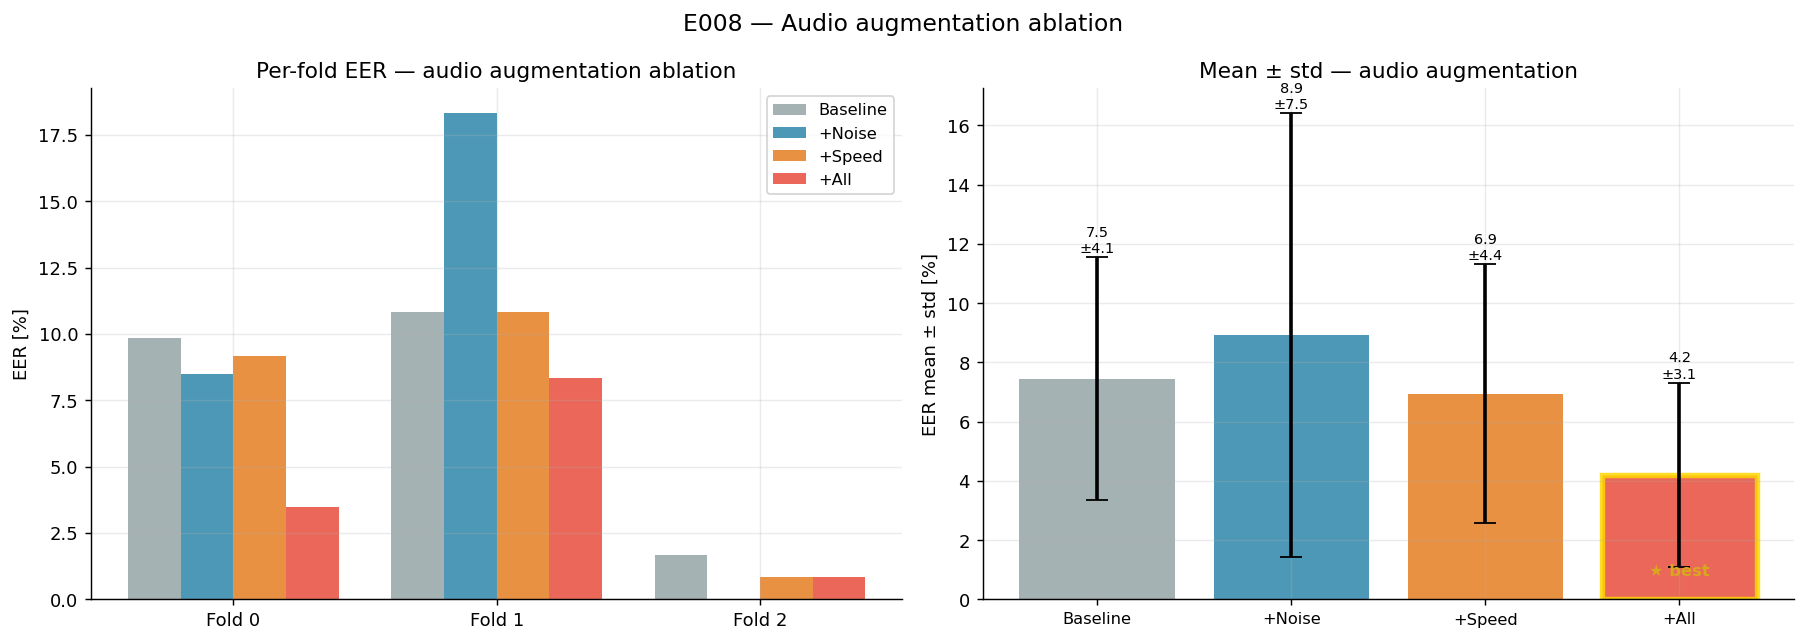

In [7]:
configs = list(all_results.keys())
n_configs = len(configs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-fold grouped bars
ax = axes[0]
x = np.arange(3)
width = 0.2
for i, (config_name, fold_results) in enumerate(all_results.items()):
    eers   = [r["eer"]*100 for r in fold_results]
    offset = (i - n_configs/2 + 0.5) * width
    ax.bar(x + offset, eers, width, label=config_name,
           color=CONFIG_COLORS[config_name], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(["Fold 0", "Fold 1", "Fold 2"])
ax.set_ylabel("EER [%]")
ax.set_title("Per-fold EER — audio augmentation ablation")
ax.legend(fontsize=9)

# Mean ± std
ax = axes[1]
means  = [np.mean([r["eer"]*100 for r in fr]) for fr in all_results.values()]
stds   = [np.std( [r["eer"]*100 for r in fr]) for fr in all_results.values()]
colors_list = [CONFIG_COLORS[c] for c in configs]
bars = ax.bar(range(n_configs), means, color=colors_list, alpha=0.85,
              yerr=stds, capsize=6, error_kw=dict(elinewidth=2))
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.15,
            f"{m:.1f}\n±{s:.1f}", ha="center", fontsize=8)
best_idx = np.argmin(means)
bars[best_idx].set_edgecolor("gold")
bars[best_idx].set_linewidth(3)
ax.annotate("★ best", xy=(best_idx, means[best_idx] - stds[best_idx] - 0.3),
            ha="center", fontsize=9, color="goldenrod", fontweight="bold")
ax.set_xticks(range(n_configs))
ax.set_xticklabels(configs, fontsize=9)
ax.set_ylabel("EER mean ± std [%]")
ax.set_title("Mean ± std — audio augmentation")

plt.suptitle("E008 — Audio augmentation ablation", fontsize=13)
plt.tight_layout()
plt.show()

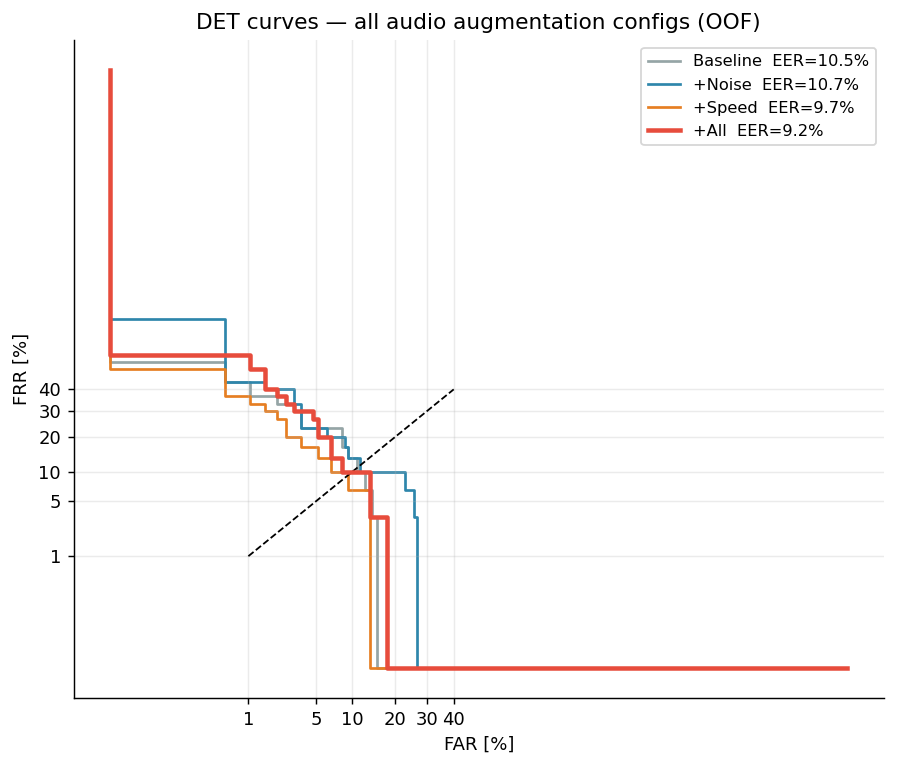

In [8]:
# DET curves for all configs + comparison with E003
ticks = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4]
tick_pos    = [scipy_norm.ppf(t) for t in ticks]
tick_labels = [f"{int(t*100)}" for t in ticks]

fig, ax = plt.subplots(figsize=(7, 6))
for config_name, oof_s in all_oof.items():
    valid = ~np.isnan(oof_s)
    fpr, tpr, _ = roc_curve(y_all[valid], oof_s[valid])
    far_c = np.clip(fpr, 1e-4, 1-1e-4)
    frr_c = np.clip(1-tpr, 1e-4, 1-1e-4)
    eer_c, _ = compute_eer(oof_s[valid & (y_all==1)], oof_s[valid & (y_all==0)])
    lw = 2.5 if config_name == best["config"] else 1.5
    ax.plot(scipy_norm.ppf(far_c), scipy_norm.ppf(frr_c),
            color=CONFIG_COLORS[config_name], lw=lw,
            label=f"{config_name}  EER={eer_c*100:.1f}%",
            zorder=5 if config_name == best["config"] else 1)

ax.plot(tick_pos, tick_pos, "k--", lw=1)
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_labels)
ax.set_xlabel("FAR [%]")
ax.set_ylabel("FRR [%]")
ax.set_title("DET curves — all audio augmentation configs (OOF)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

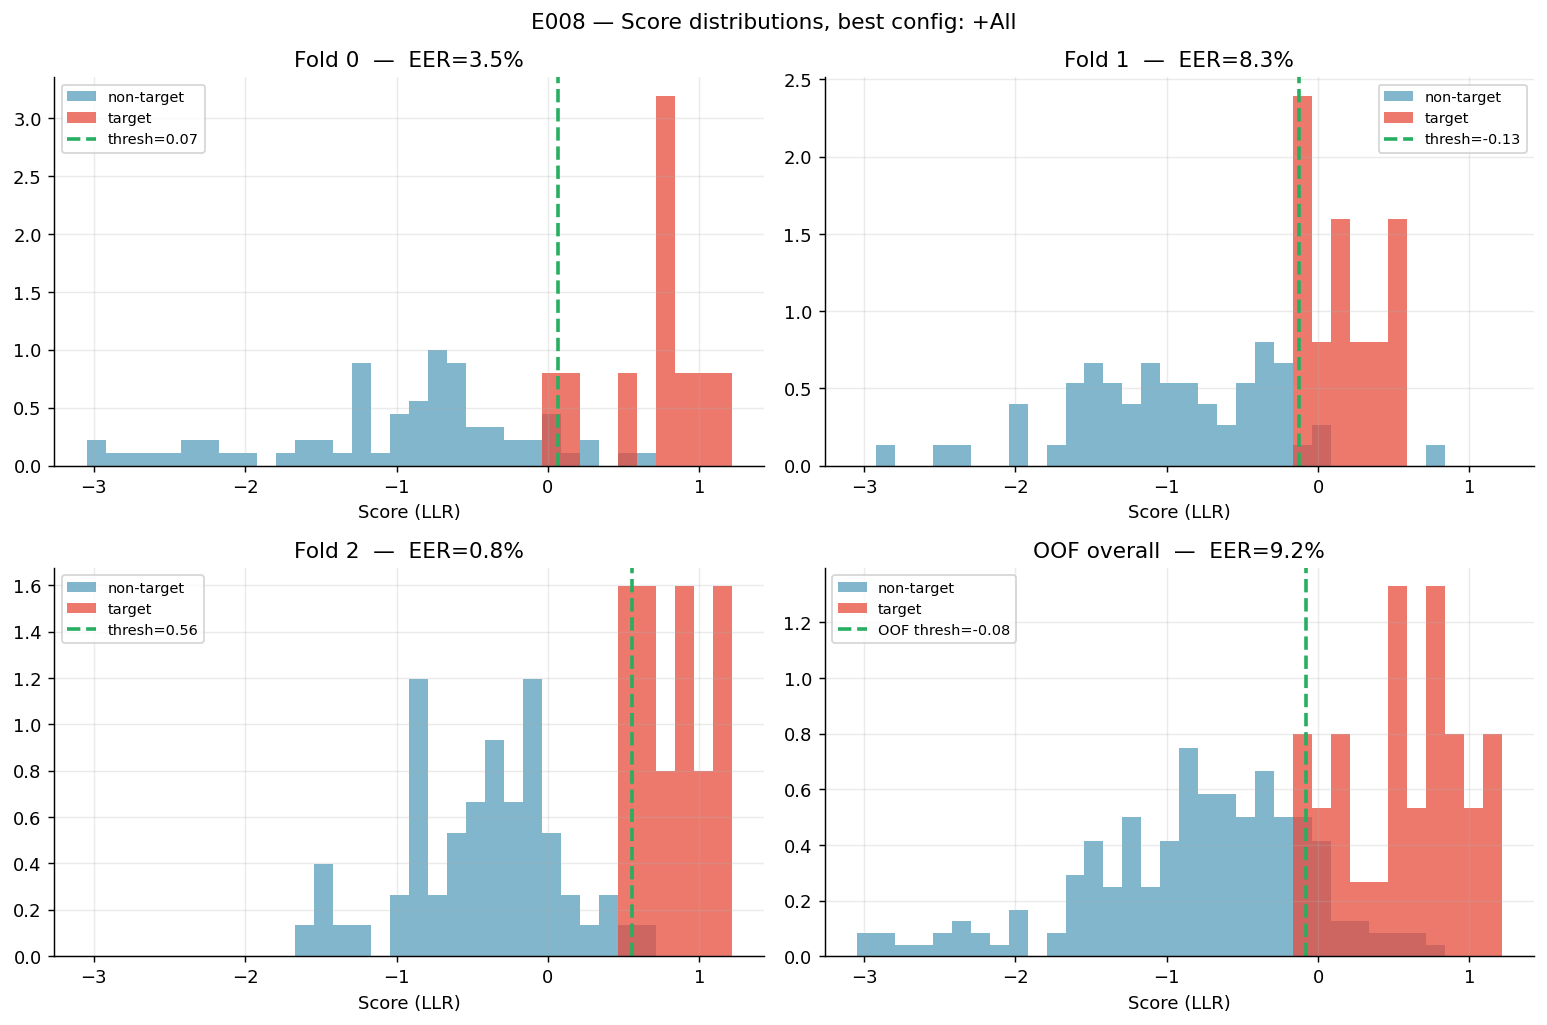

Audio flagship: E003 baseline EER=7.45±5.04%
Audio flagship: E008 best    EER=4.21±3.11%
OOF threshold: -0.077  (E003 was -0.025)


In [9]:
# Score distributions for best config
oof_best = all_oof[best["config"]]
eer_oof, _   = compute_eer(oof_best[y_all==1], oof_best[y_all==0])
dcf_oof, thr = compute_min_dcf(oof_best[y_all==1], oof_best[y_all==0])

fold_scores_best = []
for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
    fold_scores_best.append({
        "scores": oof_best[val_idx],
        "labels": manifest.loc[val_idx, "label"].to_numpy()
    })

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
bin_edges = np.linspace(np.nanmin(oof_best), np.nanmax(oof_best), 35)

for i, (ax, fdata) in enumerate(zip(axes[:3], fold_scores_best)):
    s, l = fdata["scores"], fdata["labels"]
    eer_f, thr_f = compute_eer(s[l==1], s[l==0])
    ax.hist(s[l==0], bins=bin_edges, alpha=0.6, color=COLORS["nontarget"], label="non-target", density=True)
    ax.hist(s[l==1], bins=bin_edges, alpha=0.75, color=COLORS["target"], label="target", density=True)
    ax.axvline(thr_f, color=COLORS["green"], ls="--", lw=2, label=f"thresh={thr_f:.2f}")
    ax.set_title(f"Fold {i}  —  EER={eer_f*100:.1f}%")
    ax.set_xlabel("Score (LLR)")
    ax.legend(fontsize=8)

ax = axes[3]
ax.hist(oof_best[y_all==0], bins=bin_edges, alpha=0.6, color=COLORS["nontarget"], label="non-target", density=True)
ax.hist(oof_best[y_all==1], bins=bin_edges, alpha=0.75, color=COLORS["target"], label="target", density=True)
ax.axvline(thr, color=COLORS["green"], ls="--", lw=2, label=f"OOF thresh={thr:.2f}")
ax.set_title(f"OOF overall  —  EER={eer_oof*100:.1f}%")
ax.set_xlabel("Score (LLR)")
ax.legend(fontsize=8)

plt.suptitle(f"E008 — Score distributions, best config: {best['config']}", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Audio flagship: E003 baseline EER=7.45±5.04%")
print(f"Audio flagship: E008 best    EER={best['mean']:.2f}±{best['std']:.2f}%")
print(f"OOF threshold: {thr:.3f}  (E003 was -0.025)")